In [ ]:
#Multilabel ANN
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from sklearn.datasets import load_iris
iris_data = load_iris()

print(iris_data.DESCR)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [ ]:
df = pd.DataFrame(iris_data.data , columns = iris_data.feature_names)

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
df['species'] = iris_data.target

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [ ]:

from sklearn.model_selection import train_test_split

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=42 , test_size = 0.2)

In [ ]:
len(X_train) , len(y_train)

(120, 120)

In [ ]:
len(X_test) , len(y_test)

(30, 30)

In [ ]:
X.shape

(150, 4)

In [ ]:
X.shape[1]

4

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import softmax , relu

In [ ]:
model = Sequential()
#input layer
model.add(Dense(units=64 ,
                activation='relu' ,
                kernel_initializer='he_uniform',
                input_dim = X.shape[1]
))


#Hidden layer1
model.add(Dense(units=32,
                activation='relu',
                kernel_initializer = 'he_uniform',
                 )) #input layer outputs are the inputs for hidden layer1

#Hidden layer2
model.add(Dense(units=16,
                activation='relu',
                kernel_initializer='he_uniform',
                ))

#hiddenlayer3
model.add(Dense(units=4,
                activation='relu',
                kernel_initializer='he_uniform'))

#outputlayer
model.add(Dense(units=3,
                activation='softmax',
                kernel_initializer='glorot_uniform'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,011 (11.76 KB)

 Trainable params: 3,011 (11.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              metrics=['accuracy'],
              loss= 'categorical_crossentropy')

**important for multi label**

In [ ]:
y_train_p = tf.keras.utils.to_categorical(y_train , num_classes=3)

In [ ]:
y_train_p[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [ ]:
X_train.shape

(120, 4)

In [ ]:
y_train_p.shape

(120, 3)

In [ ]:
model.fit(X_train , y_train_p,
          epochs=50,
          batch_size=1,
          validation_split = 0.1)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3479 - loss: 1.5014 - val_accuracy: 0.5833 - val_loss: 0.7760
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6577 - loss: 0.8949 - val_accuracy: 0.5833 - val_loss: 0.7370
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6666 - loss: 0.7992 - val_accuracy: 0.5833 - val_loss: 0.6699
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7715 - loss: 0.6611 - val_accuracy: 0.5833 - val_loss: 0.6403
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7118 - loss: 0.7236 - val_accuracy: 0.5833 - val_loss: 0.5833
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7480 - loss: 0.7147 - val_accuracy: 0.5833 - val_loss: 0.5534
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7413 - loss: 0.6435 - val_accuracy: 0.9167 - val_loss: 0.5297
Epoch 8/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8306 - loss: 0.5930 - val_accuracy: 1.

In [ ]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [ ]:
model.history.history['accuracy']

[0.3888888955116272,
 0.6574074029922485,
 0.7037037014961243,
 0.7222222089767456,
 0.7222222089767456,
 0.7685185074806213,
 0.8148148059844971,
 0.8796296119689941,
 0.9166666865348816,
 0.9166666865348816,
 0.9537037014961243,
 0.9629629850387573,
 0.9537037014961243,
 0.9444444179534912,
 0.9444444179534912,
 0.9444444179534912,
 0.9351851940155029,
 0.9444444179534912,
 0.9444444179534912,
 0.9444444179534912,
 0.9444444179534912,
 0.9537037014961243,
 0.9444444179534912,
 0.9444444179534912,
 0.9444444179534912,
 0.9629629850387573,
 0.9351851940155029,
 0.9444444179534912,
 0.9722222089767456,
 0.9351851940155029,
 0.9259259104728699,
 0.9537037014961243,
 0.9629629850387573,
 0.9537037014961243,
 0.9722222089767456,
 0.9351851940155029,
 0.9722222089767456,
 0.9537037014961243,
 0.9537037014961243,
 0.9259259104728699,
 0.9444444179534912,
 0.9444444179534912,
 0.9629629850387573,
 0.9629629850387573,
 0.9444444179534912,
 0.9629629850387573,
 0.9814814925193787,
 0.9444444179

In [ ]:
model.history.history['loss']

[1.0550259351730347,
 0.8111091256141663,
 0.7828809022903442,
 0.7426992058753967,
 0.7103779911994934,
 0.6750835180282593,
 0.6526156067848206,
 0.6021739840507507,
 0.575266420841217,
 0.5511986017227173,
 0.505092203617096,
 0.47933971881866455,
 0.44218724966049194,
 0.42526498436927795,
 0.3890993893146515,
 0.36461716890335083,
 0.35480764508247375,
 0.32655730843544006,
 0.32437941431999207,
 0.3018653094768524,
 0.28087449073791504,
 0.2633640468120575,
 0.2630601227283478,
 0.25820139050483704,
 0.22475562989711761,
 0.2258964627981186,
 0.22955043613910675,
 0.22732698917388916,
 0.18975546956062317,
 0.24028214812278748,
 0.20912273228168488,
 0.1936628222465515,
 0.18206487596035004,
 0.17179138958454132,
 0.140932098031044,
 0.2300703078508377,
 0.15160763263702393,
 0.16581261157989502,
 0.12900513410568237,
 0.24128927290439606,
 0.17723070085048676,
 0.16130121052265167,
 0.15195466578006744,
 0.1350104957818985,
 0.15608294308185577,
 0.15462781488895416,
 0.11765775

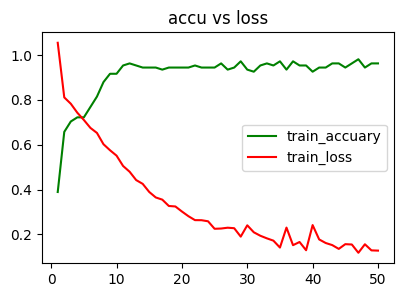

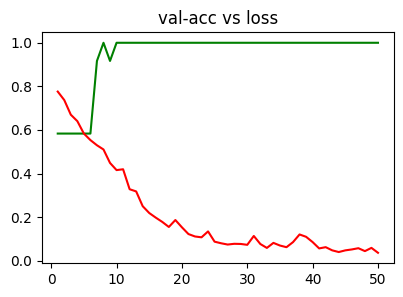

In [ ]:
plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title('accu vs loss')
plt.plot(np.arange(1,51), model.history.history['accuracy'] , label='train_accuary' , color='g')
plt.plot(np.arange(1,51) , model.history.history['loss'],
         label='train_loss' , color='r')
plt.legend(loc=0)


plt.figure(figsize=(10,3))
plt.subplot(1,2,2)
plt.title('val-acc vs loss')
plt.plot(np.arange(1,51) , model.history.history['val_accuracy'] , label='val_accuracy' , color='g')
plt.plot(np.arange(1,51) , model.history.history['val_loss'] ,
         label= 'val_loss' , color='r')
plt.show()


In [ ]:
X_test.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,6.1,2.8,4.7,1.2


In [ ]:
y_test.head(1)

,species
73,1


In [ ]:
labels = ['setosa' , 'versicolor' , 'virgenica']


In [ ]:
d = []
for i in X_test.columns:
  d.append(X_test[i][73])
print(d)

[np.float64(6.1), np.float64(2.8), np.float64(4.7), np.float64(1.2)]


In [ ]:
d = np.array(d).reshape(1,-1)
d

array([[6.1, 2.8, 4.7, 1.2]])

In [ ]:
model.predict(d)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


array([[1.24077575e-08, 9.75614190e-01, 2.43858192e-02]], dtype=float32)

In [ ]:
labels[np.argmax(model.predict(d))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


'versicolor'

In [ ]:
y_test_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [ ]:
y_test_pred[:5]

array([[1.24077335e-08, 9.75614130e-01, 2.43858639e-02],
       [9.10588801e-01, 6.19737618e-02, 2.74374131e-02],
       [5.81801604e-22, 2.25509211e-04, 9.99774456e-01],
       [3.48382678e-09, 9.20394301e-01, 7.96056837e-02],
       [2.35415865e-09, 9.80132937e-01, 1.98672060e-02]], dtype=float32)

In [ ]:
e = []
for i in y_test_pred:
  if np.argmax(i) == 0:
    e.append(0)

  elif np.argmax(i) ==1:
    e.append(1)

  else:
    e.append(2)

print(e)



[1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0]


In [ ]:
from sklearn.metrics import confusion_matrix , accuracy_score

In [ ]:
confusion_matrix(y_test , e)

array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  0, 11]])

In [ ]:
accuracy_score(y_test , e)

0.9666666666666667